In [11]:
import pandas as pd
import numpy as np
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


df = pd.read_csv(r"C:\Users\kajal\Downloads\nasa.csv")

# Clean column names
df.columns = df.columns.str.strip().str.replace(r'[^A-Za-z0-9]+', '_', regex=True)


In [12]:
df.rename(columns={
    'Rocket_Cost_of_the_mission_in_million': 'Cost'
}, inplace=True)


In [13]:

df.drop(columns=['Uname', 'Unnamed_0'], inplace=True)
print(df.columns)

Index(['Company_Name', 'Location', 'Datum', 'Detail', 'Status_Rocket', 'Cost',
       'Status_Mission', 'Rocket_Fuel', 'Environment_Impact'],
      dtype='str')


In [14]:
print(df.isnull().sum())



Company_Name             0
Location                 0
Datum                    0
Detail                   0
Status_Rocket            0
Cost                  3360
Status_Mission           0
Rocket_Fuel           4311
Environment_Impact    4311
dtype: int64


In [15]:
df["Cost"] = pd.to_numeric(df["Cost"], errors="coerce")
df.drop(columns=["Cost"], inplace=True)

print("After removing null cost rows:", df.shape)

After removing null cost rows: (4324, 8)


In [16]:
# Extract Rocket Name from Detail column
df["Rocket_Name"] = df["Detail"].str.split("|").str[0].str.strip()

# Function to assign fuel
def assign_fuel(row):
    fuel = row["Rocket_Fuel"]
    rocket = str(row["Rocket_Name"]).lower()

    # Keep existing fuel if available
    if pd.notna(fuel) and str(fuel).strip().lower() != "unknown":
        return fuel

    # Rule-based mapping
    if "falcon" in rocket:
        return "RP-1 + LOX"

    elif "starship" in rocket:
        return "Liquid Methane + LOX"

    elif "atlas" in rocket:
        return "RP-1 + LOX / Liquid Hydrogen + LOX"

    elif "delta" in rocket:
        return "Liquid Hydrogen + LOX"

    elif "ariane" in rocket:
        return "Liquid Hydrogen + LOX"

    elif "soyuz" in rocket:
        return "RP-1 + LOX"

    elif "proton" in rocket:
        return "UDMH + Nitrogen Tetroxide"

    elif "long march" in rocket:
        return "UDMH + Nitrogen Tetroxide"

    elif "pslv" in rocket:
        return "Solid + Liquid Fuel"

    elif "gslv" in rocket:
        return "Solid + Liquid + Cryogenic Fuel"

    elif "electron" in rocket:
        return "RP-1 + LOX"

    elif "vega" in rocket:
        return "Solid Rocket Fuel"

    elif "h-iia" in rocket or "h-iib" in rocket:
        return "Liquid Hydrogen + LOX"

    elif "minotaur" in rocket:
        return "Solid Rocket Fuel"

    elif "pegasus" in rocket:
        return "Solid Rocket Fuel"

    elif "new shepard" in rocket:
        return "Liquid Hydrogen + LOX"

    elif "new glenn" in rocket:
        return "Liquid Methane + LOX"

    elif "rokot" in rocket:
        return "UDMH + Nitrogen Tetroxide"

    elif "zenit" in rocket:
        return "RP-1 + LOX"

    elif "dnepr" in rocket:
        return "UDMH + Nitrogen Tetroxide"

    elif "saturn v" in rocket:
        return "RP-1 + LOX / Liquid Hydrogen + LOX"

    elif "space shuttle" in rocket:
        return "Solid Rocket Booster + Liquid Hydrogen + LOX"

    elif "titan" in rocket:
        return "UDMH + Nitrogen Tetroxide"

    elif "antares" in rocket:
        return "RP-1 + LOX"

    elif "ares" in rocket:
        return "Solid + Liquid Hydrogen + LOX"

    elif "vostok" in rocket:
        return "RP-1 + LOX"

    elif "voskhod" in rocket:
        return "RP-1 + LOX"

    elif "molniya" in rocket:
        return "RP-1 + LOX"

    elif "n1" in rocket:
        return "RP-1 + LOX"

    elif "redstone" in rocket:
        return "Alcohol + LOX"

    elif "mercury-redstone" in rocket:
        return "Alcohol + LOX"

    elif "black arrow" in rocket:
        return "Kerosene + High-Test Peroxide"

    elif "black brant" in rocket:
        return "Solid Rocket Fuel"

    elif "sounding rocket" in rocket:
        return "Solid Rocket Fuel"

    else:
        return "Unknown"

# Fill Rocket_Fuel column
df["Rocket_Fuel"] = df.apply(assign_fuel, axis=1)

# Check remaining unknown values
print(df["Rocket_Fuel"].value_counts())

# Save updated dataset
df.to_csv("launches_with_fuel.csv", index=False)

Rocket_Fuel
RP-1 + LOX                                                           1248
Unknown                                                              1244
UDMH + Nitrogen Tetroxide                                             566
Liquid Hydrogen + LOX                                                 530
RP-1 + LOX / Liquid Hydrogen + LOX                                    427
Solid Rocket Booster + Liquid Hydrogen + LOX                          135
Solid Rocket Fuel                                                      85
Solid + Liquid Fuel                                                    51
Solid + Liquid + Cryogenic Fuel                                        17
Alcohol + LOX                                                           7
Kerosene + High-Test Peroxide                                           2
RP-1 (refined kerosene) + Liquid Oxygen (LOX)                           1
UDMH (toxic fuel) + Nitrogen Tetroxide                                  1
Liquid Methane + Liquid Ox

In [17]:
print(df.isnull().sum())

Company_Name             0
Location                 0
Datum                    0
Detail                   0
Status_Rocket            0
Status_Mission           0
Rocket_Fuel              0
Environment_Impact    4311
Rocket_Name              0
dtype: int64


In [18]:
df=df[df["Rocket_Fuel"]!='Unknown']

In [19]:
print(df["Rocket_Fuel"].value_counts())

Rocket_Fuel
RP-1 + LOX                                                           1248
UDMH + Nitrogen Tetroxide                                             566
Liquid Hydrogen + LOX                                                 530
RP-1 + LOX / Liquid Hydrogen + LOX                                    427
Solid Rocket Booster + Liquid Hydrogen + LOX                          135
Solid Rocket Fuel                                                      85
Solid + Liquid Fuel                                                    51
Solid + Liquid + Cryogenic Fuel                                        17
Alcohol + LOX                                                           7
Kerosene + High-Test Peroxide                                           2
RP-1 (refined kerosene) + Liquid Oxygen (LOX)                           1
UDMH (toxic fuel) + Nitrogen Tetroxide                                  1
Liquid Methane + Liquid Oxygen                                          1
RP-1 + LOX (first stage),L

4. Fill Environment Impact Based on Rocket Fuel

In [20]:
# Function to assign environmental impact
def assign_environment_impact(fuel):

    fuel = str(fuel).lower()

    # High impact
    if "udmh" in fuel or "nitrogen tetroxide" in fuel:
        return "High"

    elif "solid rocket fuel" in fuel:
        return "High"

    # Medium impact
    elif "solid + liquid + cryogenic" in fuel:
        return "Medium"

    elif "solid + liquid fuel" in fuel:
        return "Medium"

    elif "solid rocket booster" in fuel:
        return "Medium"

    # Low impact
    elif "rp-1 + lox" in fuel:
        return "Low"

    elif "liquid methane + lox" in fuel:
        return "Low"

    elif "liquid hydrogen + lox" in fuel:
        return "Low"

    elif "kerosene + high-test peroxide" in fuel:
        return "Medium"

    elif "alcohol + lox" in fuel:
        return "Low"

    # Unknown
    else:
        return "Unknown"


# Create Environment_Impact column
df["Environment_Impact"] = df["Rocket_Fuel"].apply(assign_environment_impact)

# Check counts
print(df["Environment_Impact"].value_counts())

# Save dataset
df.to_csv("launches_with_environment.csv", index=False)




Environment_Impact
Low        2216
High        656
Medium      205
Unknown       3
Name: count, dtype: int64


In [21]:
df=df[df["Environment_Impact"]!='Unknown']

In [22]:
print("Dataset Shape:", df.shape)


Dataset Shape: (3077, 9)


In [23]:
df.to_csv("Space_Missions_Cleaned.csv", index=False)

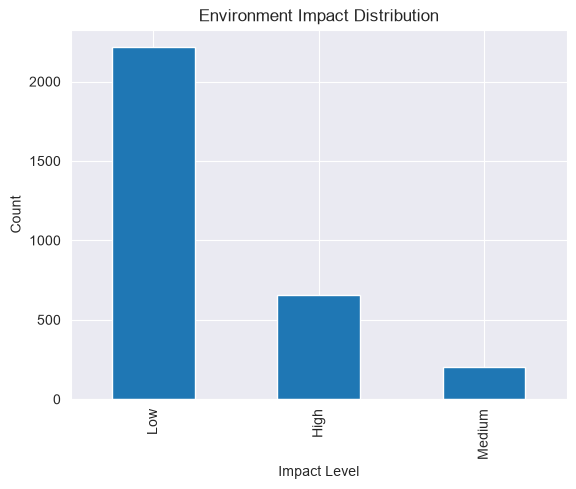

In [24]:
import matplotlib.pyplot as plt

df["Environment_Impact"].value_counts().plot(kind="bar")
plt.title("Environment Impact Distribution")
plt.xlabel("Impact Level")
plt.ylabel("Count")
plt.show()

Rocket Fuel Usage

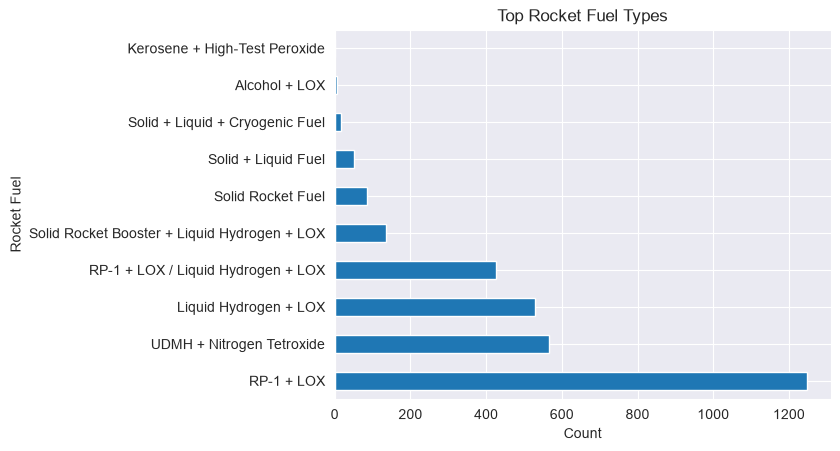

In [25]:
df["Rocket_Fuel"].value_counts().head(10).plot(kind="barh")
plt.title("Top Rocket Fuel Types")
plt.xlabel("Count")
plt.ylabel("Rocket Fuel")
plt.show()

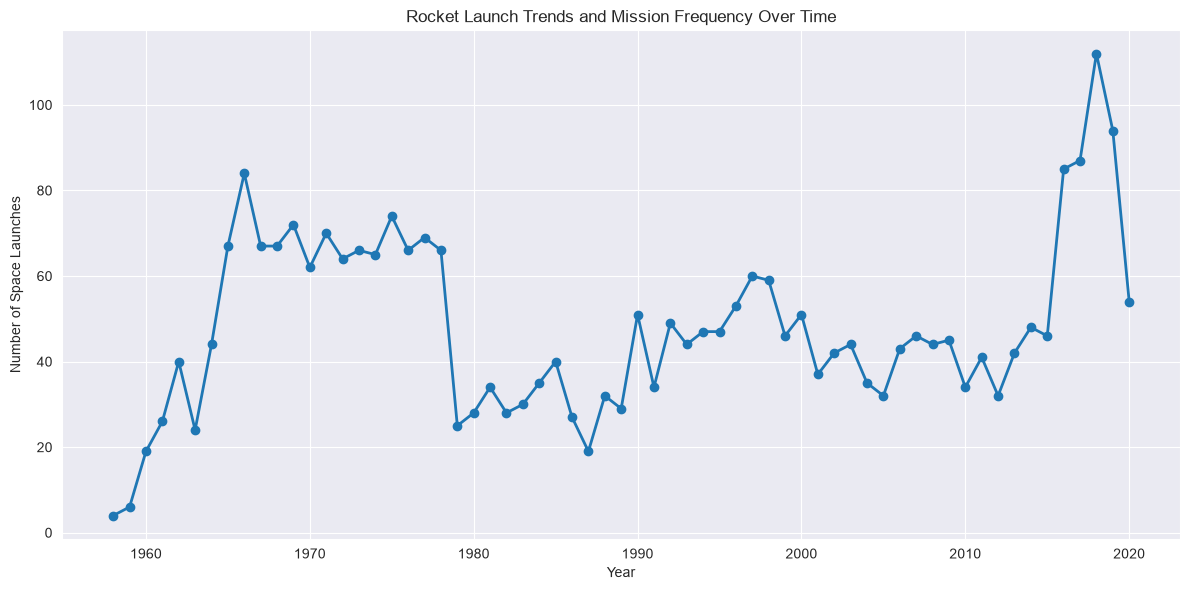

In [26]:


# If Datum column exists, convert it into datetime
df["Datum"] = pd.to_datetime(df["Datum"], errors="coerce", utc=True)

# Extract year from launch date
df["Year"] = df["Datum"].dt.year

# Count number of launches per year
launch_trend = df["Year"].value_counts().sort_index()

# Plot line chart
plt.figure(figsize=(12, 6))

plt.plot(
    launch_trend.index,
    launch_trend.values,
    marker="o",
    linewidth=2
)

plt.title("Rocket Launch Trends and Mission Frequency Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Space Launches")
plt.grid(True)

plt.tight_layout()
plt.show()

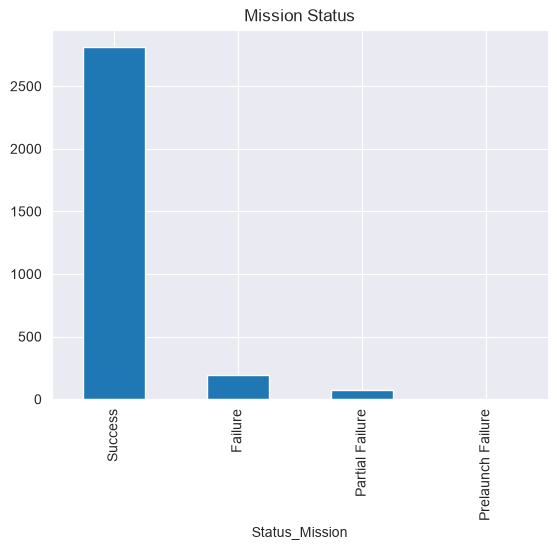

In [27]:
#Mission Success vs Failure
df["Status_Mission"].value_counts().plot(kind="bar")
plt.title("Mission Status")
plt.show()

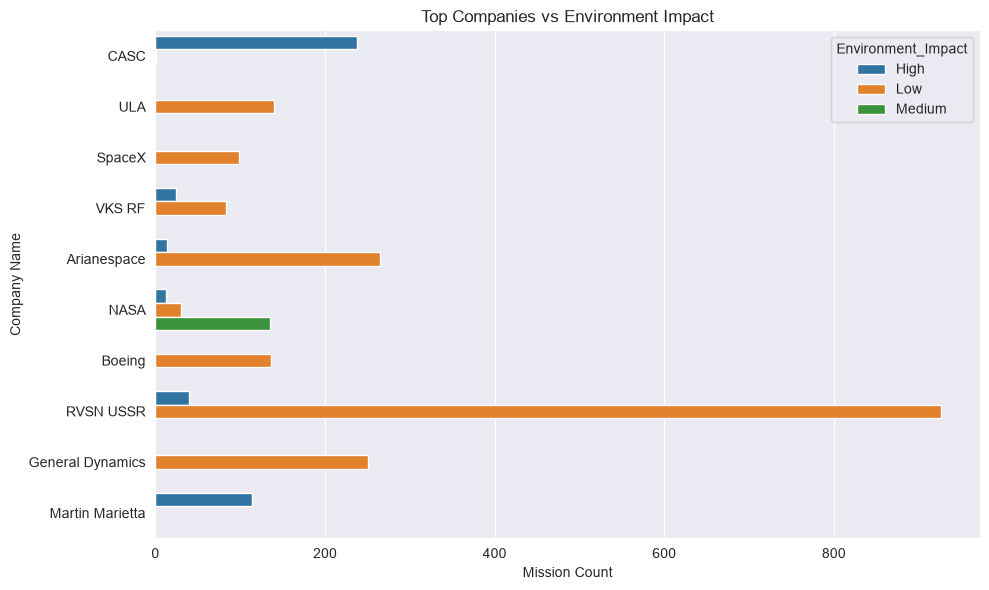

In [28]:


top_companies = df["Company_Name"].value_counts().head(10).index

plt.figure(figsize=(10, 6))

sns.countplot(
    y="Company_Name",
    hue="Environment_Impact",
    data=df[df["Company_Name"].isin(top_companies)]
)

plt.title("Top Companies vs Environment Impact")
plt.xlabel("Mission Count")
plt.ylabel("Company Name")

plt.tight_layout()
plt.show()

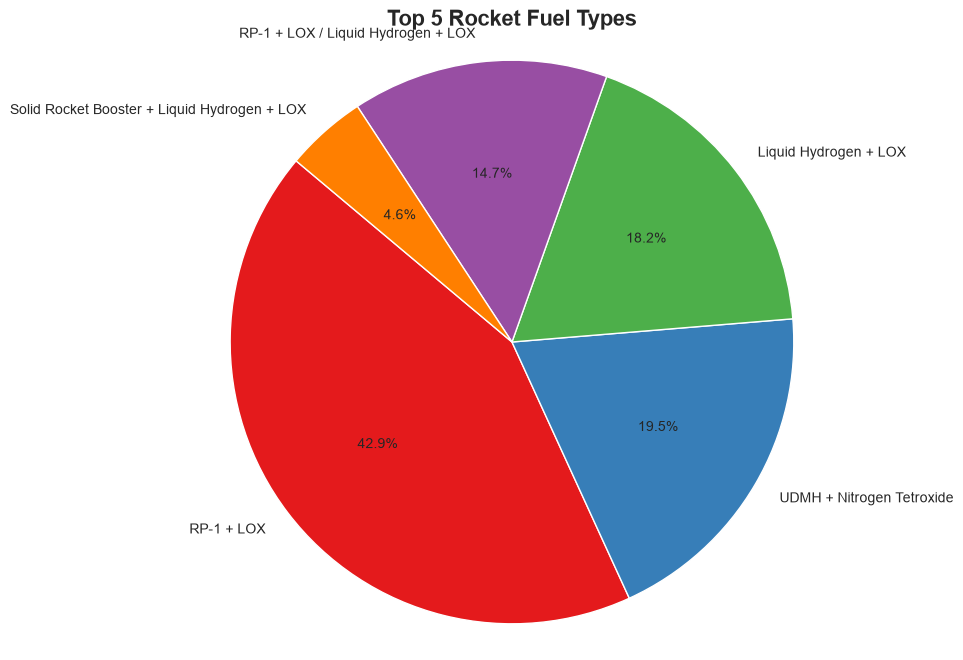

In [29]:

#pie chart
fuel_counts = df["Rocket_Fuel"].value_counts().head(5)

plt.figure(figsize=(8, 8))

plt.pie(
    fuel_counts,
    labels=fuel_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=plt.cm.Set1.colors,   # Bright colors
    wedgeprops={"edgecolor": "white"}
)

plt.title("Top 5 Rocket Fuel Types", fontsize=16, fontweight="bold")
plt.axis("equal")

plt.show()

In [30]:
X = df[
    [
        "Company_Name",
        "Location",
        "Status_Rocket",
        "Status_Mission"

    ]
]

y = df["Environment_Impact"]

In [31]:
from sklearn.preprocessing import LabelEncoder

# Encode each feature column
encoders = {}

for column in X.columns:
    le = LabelEncoder()
    X[column] = le.fit_transform(X[column])
    encoders[column] = le

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (2461, 4)
Testing Features  : (616, 4)
Training Target   : (2461,)
Testing Target    : (616,)


In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9935064935064936
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       143
           1       1.00      0.99      1.00       435
           2       0.93      1.00      0.96        38

    accuracy                           0.99       616
   macro avg       0.97      1.00      0.98       616
weighted avg       0.99      0.99      0.99       616



In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9935064935064936
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       143
           1       1.00      0.99      1.00       435
           2       0.93      1.00      0.96        38

    accuracy                           0.99       616
   macro avg       0.97      1.00      0.98       616
weighted avg       0.99      0.99      0.99       616



In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.7564935064935064
              precision    recall  f1-score   support

           0       0.79      0.26      0.39       143
           1       0.76      0.99      0.86       435
           2       0.00      0.00      0.00        38

    accuracy                           0.76       616
   macro avg       0.51      0.41      0.42       616
weighted avg       0.72      0.76      0.70       616



In [37]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.9805194805194806
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       143
           1       0.99      0.98      0.99       435
           2       0.90      1.00      0.95        38

    accuracy                           0.98       616
   macro avg       0.96      0.98      0.97       616
weighted avg       0.98      0.98      0.98       616



In [38]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.7516233766233766
              precision    recall  f1-score   support

           0       0.63      0.54      0.58       143
           1       0.80      0.89      0.84       435
           2       0.00      0.00      0.00        38

    accuracy                           0.75       616
   macro avg       0.47      0.48      0.47       616
weighted avg       0.71      0.75      0.73       616



In [39]:
from sklearn.metrics import accuracy_score

results = {
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "KNN": accuracy_score(y_test, y_pred_knn),
    "Naive Bayes": accuracy_score(y_test, y_pred_nb)
}

for model, accuracy in results.items():
    print(f"{model}: {accuracy:.4f}")

Decision Tree: 0.9935
Random Forest: 0.9935
Logistic Regression: 0.7565
KNN: 0.9805
Naive Bayes: 0.7516


In [40]:
from sklearn.metrics import accuracy_score

train_pred = dt_model.predict(X_train)
test_pred = dt_model.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy :", accuracy_score(y_test, test_pred))

Train Accuracy: 0.995530272247054
Test Accuracy : 0.9935064935064936


In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       143
           1       1.00      0.99      1.00       435
           2       0.93      1.00      0.96        38

    accuracy                           0.99       616
   macro avg       0.97      1.00      0.98       616
weighted avg       0.99      0.99      0.99       616



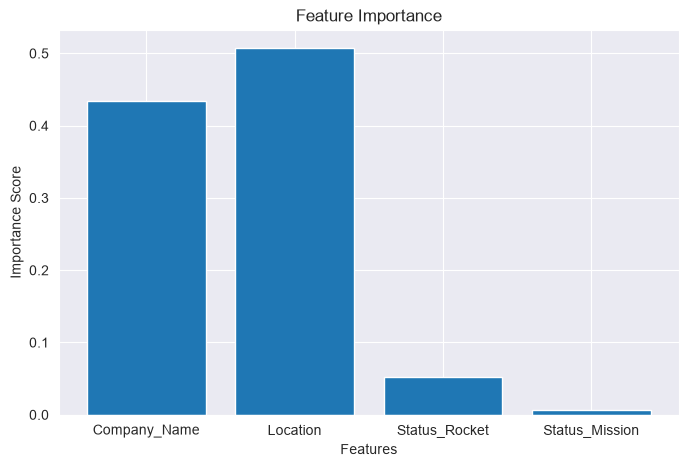

In [42]:
import matplotlib.pyplot as plt

# Get importance score of each feature
importance = rf_model.feature_importances_

# Feature names
features = X.columns

# Plot
plt.figure(figsize=(8,5))
plt.bar(features, importance)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.show()

In [46]:
best_model = max(results, key=results.get)

print("Best Model:", best_model)

Best Model: Decision Tree


In [49]:
results = {
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "KNN": accuracy_score(y_test, y_pred_knn),
    "Naive Bayes": accuracy_score(y_test, y_pred_nb)
}
for model, accuracy in results.items():
    print(f"{model}: {accuracy:.4f}")

Decision Tree: 0.9935
Random Forest: 0.9935
Logistic Regression: 0.7565
KNN: 0.9805
Naive Bayes: 0.7516


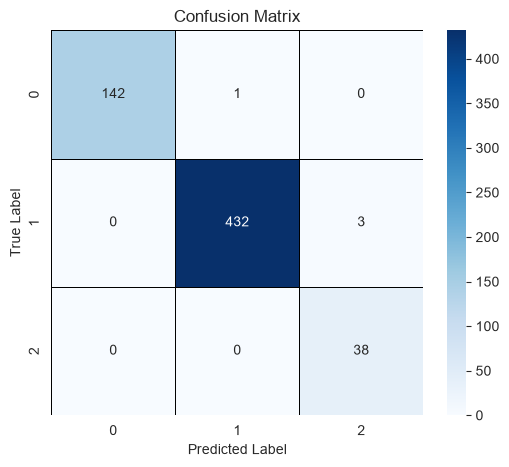

In [53]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="black"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [55]:
# Final model
model = rf_model

In [56]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# Dropdown values
company_options = sorted(df["Company_Name"].unique())
location_options = sorted(df["Location"].unique())
rocket_status_options = sorted(df["Status_Rocket"].unique())
mission_status_options = sorted(df["Status_Mission"].unique())

# Dropdowns
company = widgets.Dropdown(
    options=company_options,
    description="Company:"
)

location = widgets.Dropdown(
    options=location_options,
    description="Location:"
)

rocket_status = widgets.Dropdown(
    options=rocket_status_options,
    description="Rocket:"
)

mission_status = widgets.Dropdown(
    options=mission_status_options,
    description="Mission:"
)

# Button
button = widgets.Button(
    description="Predict",
    button_style="success"
)

# Output
output = widgets.Output()

In [57]:
def predict(b):

    output.clear_output()

    # Create input
    new_data = pd.DataFrame([{
        "Company_Name": company.value,
        "Location": location.value,
        "Status_Rocket": rocket_status.value,
        "Status_Mission": mission_status.value
    }])

    # Encode input
    for col in new_data.columns:
        new_data[col] = encoders[col].transform(new_data[col])

    # Prediction
    pred = model.predict(new_data)[0]

    # Convert number back to text
    pred = target_encoder.inverse_transform([pred])[0]

    with output:
        print("Prediction :", pred)

In [58]:
button.on_click(predict)
display(company)
display(location)
display(rocket_status)
display(mission_status)
display(button)
display(output)

Dropdown(description='Company:', options=('AMBA', 'Arianespace', 'Blue Origin', 'Boeing', 'CASC', 'Douglas', '…

Dropdown(description='Location:', options=('Blue Origin Launch Site, West Texas, Texas, USA', 'ELA-1, Guiana S…

Dropdown(description='Rocket:', options=('StatusActive', 'StatusRetired'), value='StatusActive')

Dropdown(description='Mission:', options=('Failure', 'Partial Failure', 'Prelaunch Failure', 'Success'), value…

Button(button_style='success', description='Predict', style=ButtonStyle())

Output()